Improting the Required modules 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast

Loading and  initial cleaning 

In [2]:
df = pd.read_csv('raw_titles.csv')
df.head()

,index,id,title,type,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes
0,0,ts300399,Five Came Back: The Reference Films,SHOW,1945,TV-MA,48,['documentation'],['US'],1.0,NaN,NaN,NaN
1,1,tm84618,Taxi Driver,MOVIE,1976,R,113,"['crime', 'drama']",['US'],NaN,tt0075314,8.3,795222.0
2,2,tm127384,Monty Python and the Holy Grail,MOVIE,1975,PG,91,"['comedy', 'fantasy']",['GB'],NaN,tt0071853,8.2,530877.0
3,3,tm70993,Life of Brian,MOVIE,1979,R,94,['comedy'],['GB'],NaN,tt0079470,8.0,392419.0
4,4,tm190788,The Exorcist,MOVIE,1973,R,133,['horror'],['US'],NaN,tt0070047,8.1,391942.0


In [3]:
df=df.drop(columns=['index'])
df.head()

,id,title,type,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes
0,ts300399,Five Came Back: The Reference Films,SHOW,1945,TV-MA,48,['documentation'],['US'],1.0,NaN,NaN,NaN
1,tm84618,Taxi Driver,MOVIE,1976,R,113,"['crime', 'drama']",['US'],NaN,tt0075314,8.3,795222.0
2,tm127384,Monty Python and the Holy Grail,MOVIE,1975,PG,91,"['comedy', 'fantasy']",['GB'],NaN,tt0071853,8.2,530877.0
3,tm70993,Life of Brian,MOVIE,1979,R,94,['comedy'],['GB'],NaN,tt0079470,8.0,392419.0
4,tm190788,The Exorcist,MOVIE,1973,R,133,['horror'],['US'],NaN,tt0070047,8.1,391942.0


Converting genres and production_countries  to proper python list

In [4]:
def clean_list(x):
    try:
        return ast.literal_eval(x)
    except:
        return []

In [5]:
df['genres_cleaned'] = df['genres'].apply(clean_list)
df['countries_list'] = df['production_countries'].apply(clean_list)
df.head()

,id,title,type,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,genres_cleaned,countries_list
0,ts300399,Five Came Back: The Reference Films,SHOW,1945,TV-MA,48,['documentation'],['US'],1.0,NaN,NaN,NaN,[documentation],[US]
1,tm84618,Taxi Driver,MOVIE,1976,R,113,"['crime', 'drama']",['US'],NaN,tt0075314,8.3,795222.0,"[crime, drama]",[US]
2,tm127384,Monty Python and the Holy Grail,MOVIE,1975,PG,91,"['comedy', 'fantasy']",['GB'],NaN,tt0071853,8.2,530877.0,"[comedy, fantasy]",[GB]
3,tm70993,Life of Brian,MOVIE,1979,R,94,['comedy'],['GB'],NaN,tt0079470,8.0,392419.0,[comedy],[GB]
4,tm190788,The Exorcist,MOVIE,1973,R,133,['horror'],['US'],NaN,tt0070047,8.1,391942.0,[horror],[US]


In [6]:
df=df.drop(columns=['genres','production_countries'])
df.head()

,id,title,type,release_year,age_certification,runtime,seasons,imdb_id,imdb_score,imdb_votes,genres_cleaned,countries_list
0,ts300399,Five Came Back: The Reference Films,SHOW,1945,TV-MA,48,1.0,NaN,NaN,NaN,[documentation],[US]
1,tm84618,Taxi Driver,MOVIE,1976,R,113,NaN,tt0075314,8.3,795222.0,"[crime, drama]",[US]
2,tm127384,Monty Python and the Holy Grail,MOVIE,1975,PG,91,NaN,tt0071853,8.2,530877.0,"[comedy, fantasy]",[GB]
3,tm70993,Life of Brian,MOVIE,1979,R,94,NaN,tt0079470,8.0,392419.0,[comedy],[GB]
4,tm190788,The Exorcist,MOVIE,1973,R,133,NaN,tt0070047,8.1,391942.0,[horror],[US]


Exploring the types based on titles 

In [7]:
type_counts = df['type'].value_counts()
type_counts

type
MOVIE    3759
SHOW     2047
Name: count, dtype: int64

Diving into the data and exploring the treand from year 2000 for latest information

In [8]:
year_trends = df[df['release_year'] >= 2000].groupby(['release_year', 'type']).size().reset_index(name='count')
year_trends

,release_year,type,count
0,2000,MOVIE,8
1,2000,SHOW,5
2,2001,MOVIE,18
3,2001,SHOW,6
4,2002,MOVIE,13
5,2002,SHOW,8
6,2003,MOVIE,24
7,2003,SHOW,9
8,2004,MOVIE,29
9,2004,SHOW,6


In [9]:
exploded_genres= df.explode('genres_cleaned')
exploded_genres

,id,title,type,release_year,age_certification,runtime,seasons,imdb_id,imdb_score,imdb_votes,genres_cleaned,countries_list
0,ts300399,Five Came Back: The Reference Films,SHOW,1945,TV-MA,48,1.0,NaN,NaN,NaN,documentation,[US]
1,tm84618,Taxi Driver,MOVIE,1976,R,113,NaN,tt0075314,8.3,795222.0,crime,[US]
1,tm84618,Taxi Driver,MOVIE,1976,R,113,NaN,tt0075314,8.3,795222.0,drama,[US]
2,tm127384,Monty Python and the Holy Grail,MOVIE,1975,PG,91,NaN,tt0071853,8.2,530877.0,comedy,[GB]
2,tm127384,Monty Python and the Holy Grail,MOVIE,1975,PG,91,NaN,tt0071853,8.2,530877.0,fantasy,[GB]
...,...,...,...,...,...,...,...,...,...,...,...,...
5804,tm1098060,Shadow Parties,MOVIE,2021,NaN,116,NaN,tt10168094,6.2,9.0,action,[]
5804,tm1098060,Shadow Parties,MOVIE,2021,NaN,116,NaN,tt10168094,6.2,9.0,thriller,[]
5805,ts271048,Mighty Little Bheem: Kite Festival,SHOW,2021,NaN,0,1.0,tt13711094,8.8,16.0,family,[]
5805,ts271048,Mighty Little Bheem: Kite Festival,SHOW,2021,NaN,0,1.0,tt13711094,8.8,16.0,comedy,[]


In [10]:
top_10_genres = exploded_genres['genres_cleaned'].value_counts().head(10)
top_10_genres

genres_cleaned
drama            2901
comedy           2269
thriller         1178
action           1053
romance           958
documentation     910
crime             891
animation         665
fantasy           631
family            622
Name: count, dtype: int64

In [11]:
top_10_years = df['release_year'].value_counts().head(10).reset_index()
top_10_years.columns = ['Year', 'Count']
top_10_years

,Year,Count
0,2019,848
1,2020,805
2,2018,774
3,2021,758
4,2017,580
5,2016,371
6,2015,236
7,2022,217
8,2014,160
9,2013,142


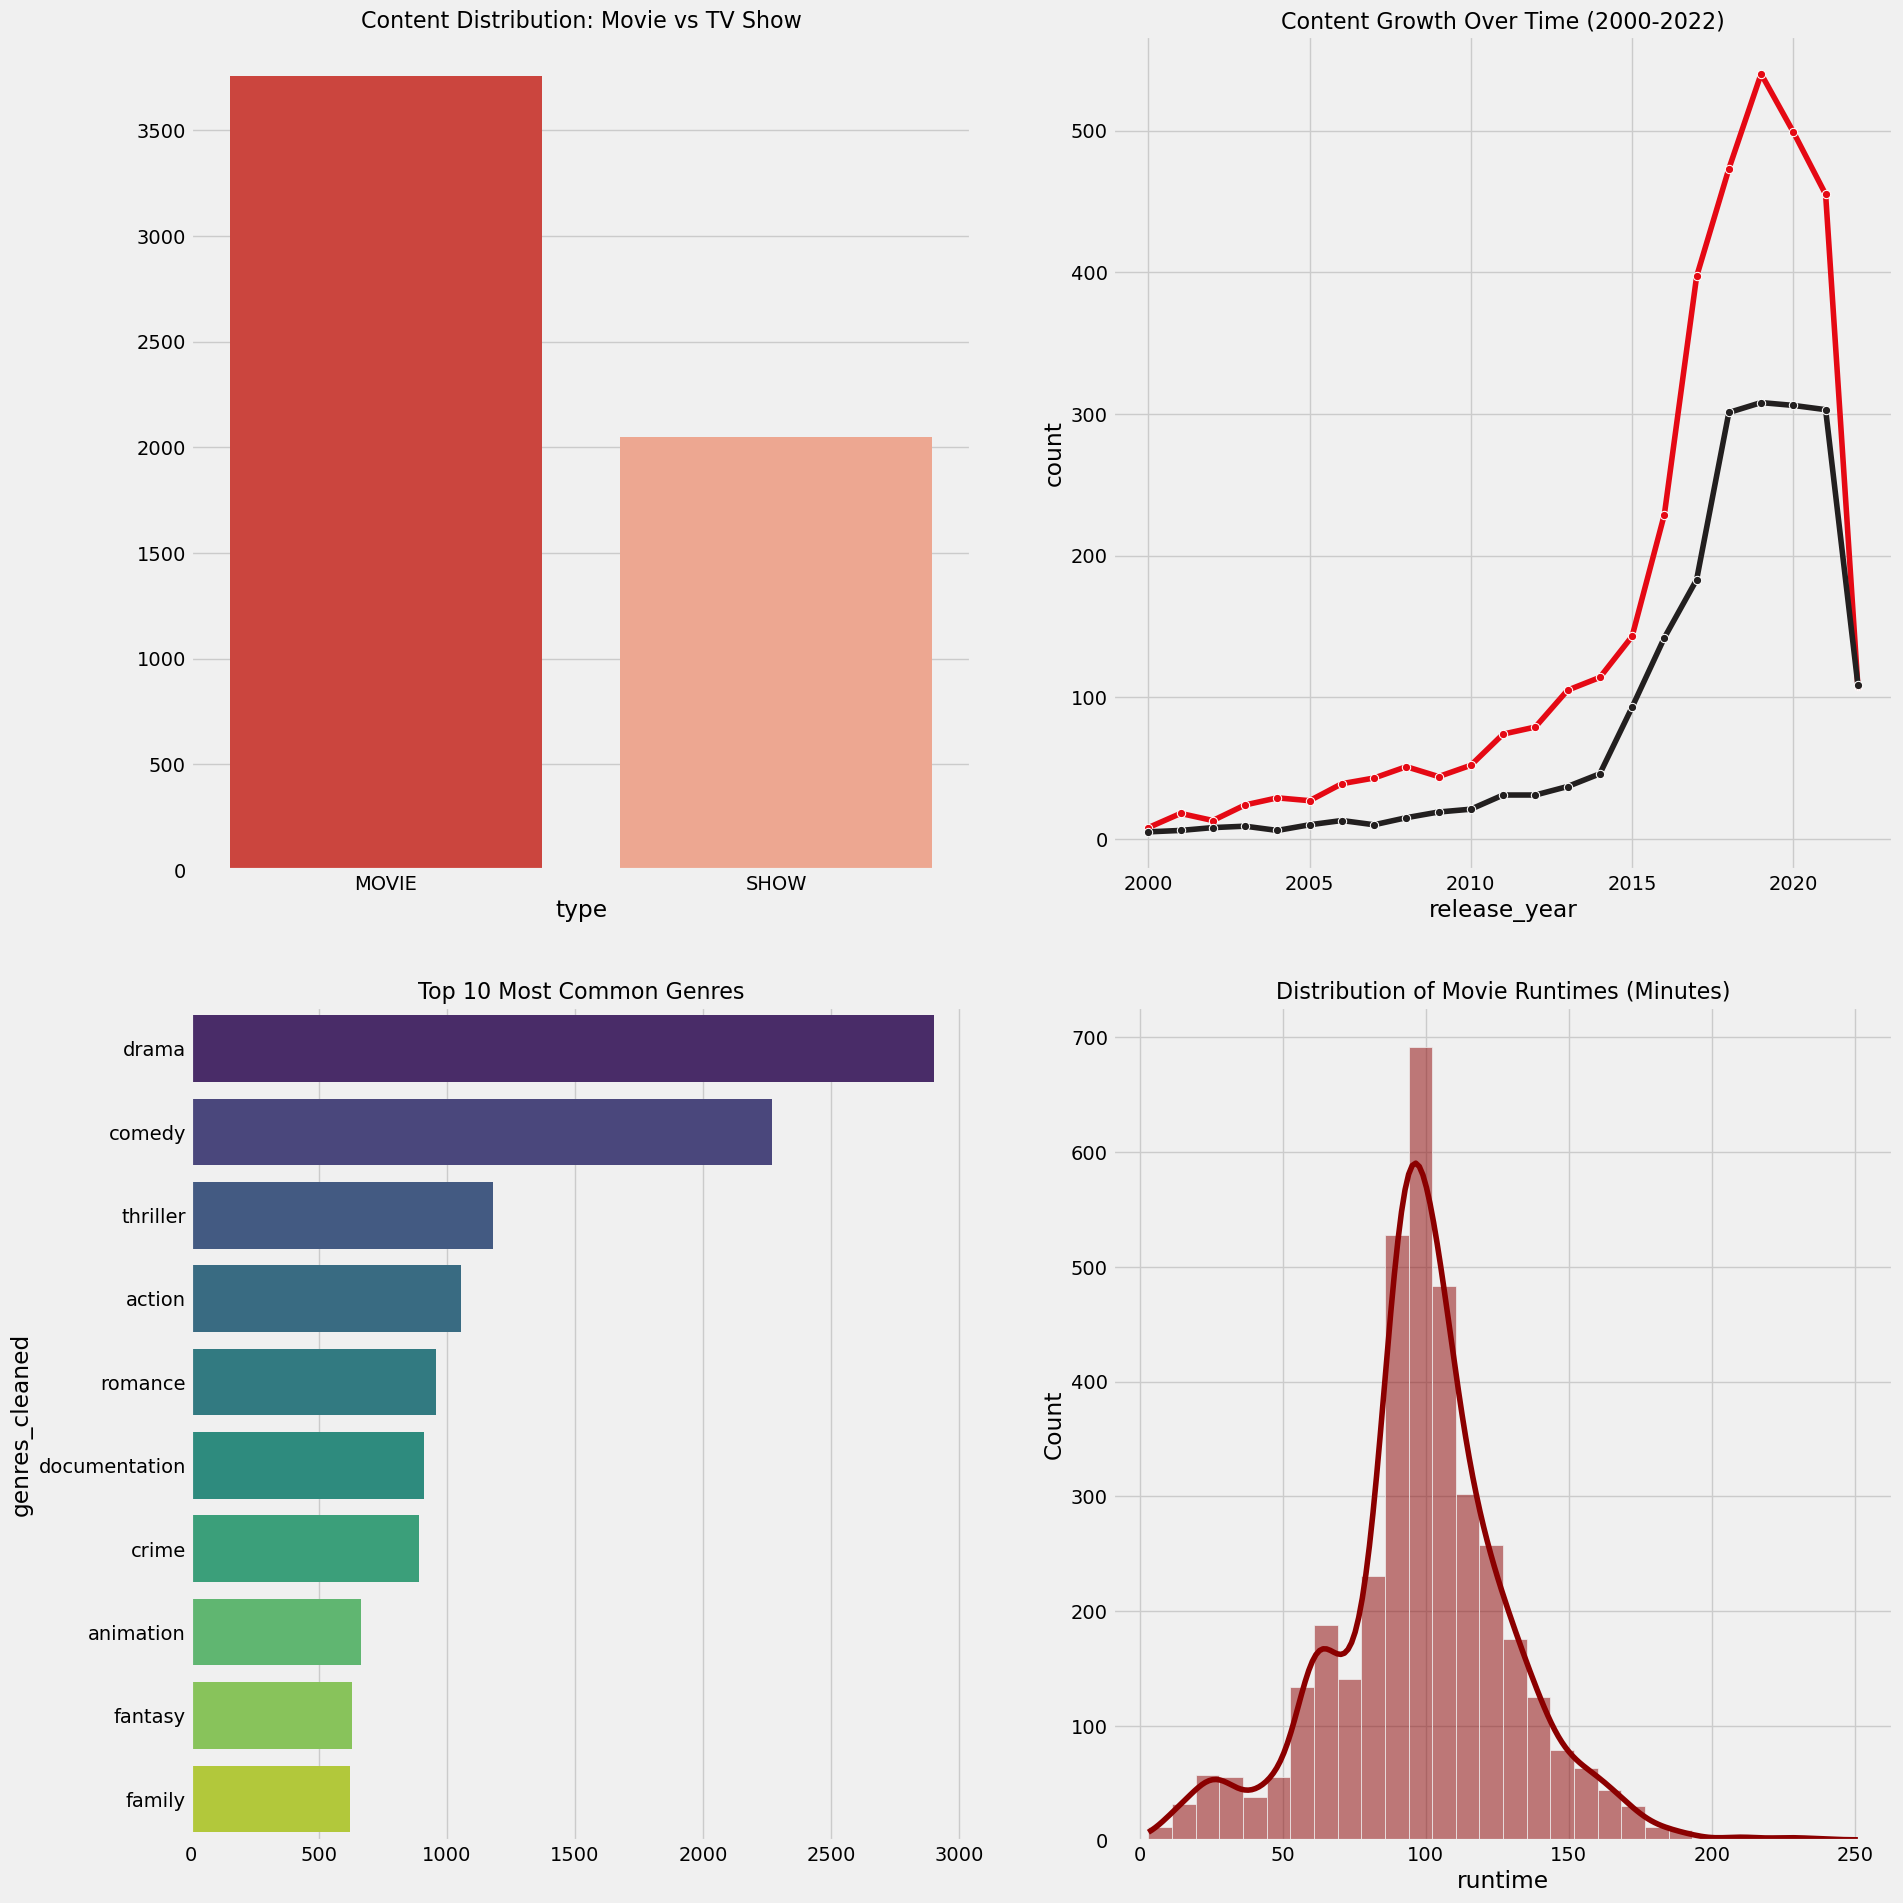

In [15]:
plt.style.use('fivethirtyeight') 
fig, axes = plt.subplots(2,2, figsize=(20, 20))
sns.barplot(x=type_counts.index, y=type_counts.values, hue=type_counts.index,ax=axes[0,0], palette='Reds_r',legend=False)
axes[0,0].set_title('Content Distribution: Movie vs TV Show', fontsize=16)
sns.lineplot(data=year_trends, x='release_year', y='count', hue='type', ax=axes[0,1], marker='o', palette=['#E50914', '#221f1f'],legend=False)
axes[0,1].set_title('Content Growth Over Time (2000-2022)', fontsize=16)
sns.barplot(x=top_10_genres.values, y=top_10_genres.index, hue=top_10_genres.index,ax=axes[1,0], palette='viridis',legend=False)
axes[1,0].set_title('Top 10 Most Common Genres', fontsize=16)
sns.histplot(df[df['type'] == 'MOVIE']['runtime'], bins=30, kde=True, ax=axes[1,1], color='darkred')
axes[1,1].set_title('Distribution of Movie Runtimes (Minutes)', fontsize=16);
plt.tight_layout(pad=3.0)
plt.savefig('netflix_visual_report.jpeg');

In [16]:
summary_text = f"""
NETFLIX EDA SUMMARY REPORT
==========================
Total Titles in Dataset: {len(df)}
Number of Movies: {type_counts.get('MOVIE', 0)}
Number of TV Shows: {type_counts.get('SHOW', 0)}

STATISTICS:
- Most Productive Year: {top_10_years.iloc[0]['Year']} ({top_10_years.iloc[0]['Count']} releases)
- Average Movie Duration: {df[df['type']=='MOVIE']['runtime'].mean():.2f} minutes
- Top Genre overall: {top_10_genres.index[0]}

TOP 10 YEARS (BY RELEASE COUNT):
{top_10_years.to_string(index=False)}
"""

with open('summary_report.txt', 'w') as f:
    f.write(summary_text)